In [ ]:
# Business Context:
# Data analyst at a B2C subscription company (telecom/SaaS/insurance). 
# Marketing spent $2M on acquisition last quarter, but churn rate is 25%. 
# Leadership asks "Why are customers leaving and how do we fix it?"

# Business Problem: 
# Company: Telecom provider with 7,043 customers
# Issue: 25% annual churn rate
# Cost: Acquiring new customer = $500, Retaining = $50
# Leadership Question: "What drives churn and how do we reduce it?"

# Key Questions:
# 1. What customer segments have highest churn risk?
# 2. What behaviors predict churn?
# 3. What interventions could reduce churn (e.g. by 5%)?
# 4. What's the ROI of retention campaigns?

# Hypotheses to Test: 
# H1. Customers with high monthly charges are more likely to churn.
# H2. Customers with month-to-month contracts have higher churn rates.
# H3. Long-term customers (over 2 years) have lower churn rates.
# H4. Customers using multiple services (internet, phone, TV) are less likely to churn. 
# H5. Customers without tech support are more likely to churn.

In [ ]:
# 2. Setup ----

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load Data
df = pd.read_csv('telco_customer_churn.csv')

# Check Data
# df.columns
# df.shape
# df.describe()
# df.head()
df.info()

In [ ]:
# Convert Total Charges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Check Senior Citizen values
df['SeniorCitizen'].value_counts()

# Convert Senior Citizen to categorical
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('object')

In [ ]:
# Recheck Data Info
df.info()

In [ ]:
# Check for Duplicates: Duplicates = 0
df.duplicated().sum()

In [ ]:
# Check for Missing Values: Missing Values = 11
df.isnull().sum()

# Check rows with nulls
# df[df.isnull().any(axis = 1)]

# Check specific row with null TotalCharges
# df.query("customerID == '4472-LVYGI'")

In [ ]:
# Check unique values per column
df.nunique()

In [ ]:
# View top 10 customers with highest tenure
df.sort_values(by = "tenure", ascending = False).head(10)

In [ ]:
# Cramer's V instead of .corr() as data is categorical. Cramer's V is derived from Chi-Squared statistic.
# "What fraction of the maximum possible chi-square association is observed in the data?"
def cramers_v(x, y):
    # Create a contingency table (cross-tabulation) of counts between the two categorical variables
    # Rows = unique values in x, Columns = unique values in y
    confusion_matrix = pd.crosstab(x, y)

    # Perform Chi-square test of independence on the contingency table
    # chi2_contingency returns (chi2_statistic, p_value, degrees_of_freedom, expected_freq_table)
    # We only need the chi2_statistic, which measures how strongly the variables deviate from independence
    chi2 = chi2_contingency(confusion_matrix)[0]

    # Get the total number of observations (n)
    # .sum() twice because the first sums columns → series of column totals,
    # second sums that series to get total count
    n = confusion_matrix.sum().sum()

    # Compute Cramér's V using the formula:
    # V = sqrt( (chi2 / n) / (min(k-1, r-1)) )
    # where k = number of columns, r = number of rows in the contingency table
    # min(confusion_matrix.shape) gives the smaller of (rows, columns)
    # subtract 1 to normalize the statistic to the 0–1 range
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

# Select only categorical columns. Exclude 'customerID' as it's an identifier
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
categorical_cols = categorical_cols.difference(['customerID'])

# Create an empty DataFrame to store Cramer's V results
cramers_v_matrix = pd.DataFrame(index = categorical_cols, columns = categorical_cols, dtype = float)

for i, col1 in enumerate(categorical_cols): # i = row index, col1 = column name
    for j, col2 in enumerate(categorical_cols): # j = column index, col2 = column name
        # Skip computation for the lower triangle (already mirrored)
        if j < i:
            # Only compute upper triangle to save time; lower triangle will be filled later
            continue
        # Compute Cramér's V between the two categorical columns
        v = cramers_v(df[col1], df[col2])

        # Store the value in the matrix at the [row=col1, column=col2] position
        cramers_v_matrix.loc[col1, col2] = v
        
        # Mirror the value to the lower triangle [row=col2, column=col1]
        cramers_v_matrix.loc[col2, col1] = v  # ensures the matrix is symmetric

# Plot categorical heatmap
plt.figure(figsize = (12, 10))
sns.heatmap(cramers_v_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = 0, vmax = 1)
plt.title("Cramer's V Heatmap for Categorical Variables")
plt.show()

In [ ]:
# Plot numerical heatmap
plt.figure(figsize = (6, 5))
sns.heatmap(df.select_dtypes(include = [np.number]).corr(), annot = True, fmt = ".2f", cmap = "coolwarm", vmin = 0, vmax = 1)
plt.title("Correlation Heatmap for Numerical Variables")
plt.show()

In [ ]:
# Univariate Analysis and Visualisations

# Categorical columns distribution by Churn
for col in categorical_cols:
    if col != 'Churn':
        sns.countplot(data = df, x = col, hue = 'Churn')
        plt.xticks(rotation = 45)
        plt.show()

In [ ]:
# Numerical columns distribution by Churn
num_cols = df.select_dtypes(include = [np.number]).columns
for col in num_cols:
    sns.histplot(data = df, x = col, hue = 'Churn', kde = True)
    plt.title(f'Distribution of {col} by Churn')
    plt.show()

    sns.boxplot(x = 'Churn', y = col, data = df)
    plt.show()

In [ ]:
# Bivariate Analysis and Visualisations
# Categorical: Pivot tables
for col in categorical_cols:
    if col != 'Churn':
        print(pd.crosstab(df[col], df['Churn'], normalize = 'index'))

# Results from crosstab above show that: 
# - month-to-month contracts (0.43), device protection (0.39), fiber optic internet (0.42), senior citizens (0.42), electronic check payment method (0.45)
# - no online backup (0.40), no online security (0.41) and no tech support (0.42) are associated with higher churn rates.

# Numerical: Grouped boxplots and histograms
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = df)
plt.show()

# Numerical: Grouped boxplots and histograms
sns.boxplot(x = 'Churn', y = 'tenure', data = df)
plt.show()

# Results from boxplots above show that: higher monthly charges and lower tenure are associated with higher churn rates.

In [ ]:
# Segmentation and Feature Interactions
# Per-segment churn rates
churn_rate = pd.pivot_table(df, index = 'Contract', columns = 'PaymentMethod', values = 'Churn', aggfunc = lambda x: (x == 'Yes').mean())
# Overall churn rate across all customers
overall_churn = (df['Churn'] == 'Yes').mean()
# Segments where churn rate is higher than expected
high_risk = churn_rate > overall_churn

print(f"Overall churn rate: {overall_churn:.2%} \n")
print(f"Churn rates (proportions): \n {churn_rate.round(3)} \n")
print(f"High-risk segments (above average churn = True): \n {high_risk}")

plt.figure(figsize=(5, 3))
sns.heatmap(churn_rate, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = 0, vmax = 1, center = overall_churn)
plt.title(f"Churn Rate by Contract & Payment Method \n (Overall avg: {overall_churn:.1%})")
plt.show()

In [ ]:
# Check churn rates by tenure groups
bins = [0, 12, 24, 48, 60, 100]
labels = ['0-12m', '13-24m', '25-48m', '49-72m', '60m+']

df['TenureGroup'] = pd.cut(df['tenure'], bins = bins, labels = labels, right = False)

tenure_churn = df.groupby('TenureGroup', observed = False)['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()

# 0-12m TenureGroup has the highest churn rate at 48%
print(tenure_churn)

In [ ]:
# Short-tenure customers (0-12 months) with month-to-month contracts have the highest churn rates: 0.52
pd.crosstab(df['TenureGroup'], df['Contract'], values = df['Churn'], aggfunc = lambda x: (x == 'Yes').mean())

In [ ]:
# Electronic check payment method with month-to-month contracts have the highest churn rates: 0.54
pd.crosstab(df['PaymentMethod'], df['Contract'], values = df['Churn'], aggfunc = lambda x: (x == 'Yes').mean())

In [ ]:
# Electronic check payment with short-tenure (0-12 months) customers have the highest churn rates: 0.63
pd.crosstab(df['PaymentMethod'], df['TenureGroup'], values = df['Churn'], aggfunc = lambda x: (x == 'Yes').mean())

In [ ]:
df['MonthlyChargeGroup'] = pd.cut(df['MonthlyCharges'], bins = [0, 50, 90, 120], labels = ['Low', 'Medium', 'High'], right = False)

pd.crosstab(df['MonthlyChargeGroup'], df['Churn'], normalize = 'index')

Churn,No,Yes
MonthlyChargeGroup,,
Low,0.84,0.16
Medium,0.71,0.29
High,0.66,0.34


<Axes: xlabel='MonthlyChargeGroup', ylabel='Churn'>

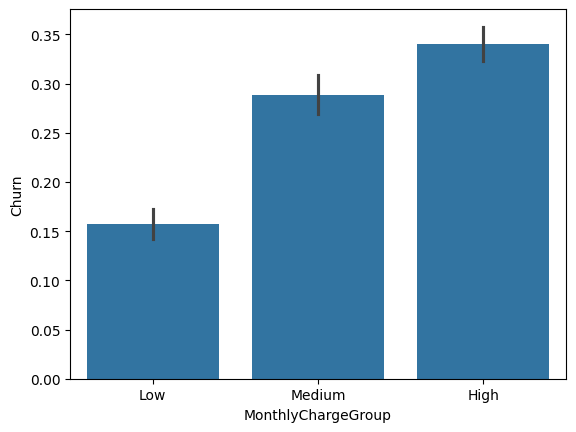